# Customer Sentiment Analysis – iPhone 15 (128GB)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving reviews_iphone15_320.csv to reviews_iphone15_320.csv


In [ ]:
1. Load Dataset

In [3]:

import pandas as pd
df = pd.read_csv("reviews_iphone15_320.csv")
df.head()


,Username,Rating,Review
0,user_1,5,Great upgrade from previous model
1,user_2,5,Best iPhone I have used so far
2,user_3,4,Camera is outstanding especially in low light
3,user_4,4,Amazing camera quality and smooth performance
4,user_5,4,Display is bright and sharp


## 2. Data Cleaning

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Username,Rating,Review,Cleaned_Review
0,user_1,5,Great upgrade from previous model,great upgrade previous model
1,user_2,5,Best iPhone I have used so far,best iphone used far
2,user_3,4,Camera is outstanding especially in low light,camera outstanding especially low light
3,user_4,4,Amazing camera quality and smooth performance,amazing camera quality smooth performance
4,user_5,4,Display is bright and sharp,display bright sharp


## 3. Text Preprocessing

In [6]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Username,Rating,Review,Cleaned_Review
0,user_1,5,Great upgrade from previous model,great upgrade previous model
1,user_2,5,Best iPhone I have used so far,best iphone used far
2,user_3,4,Camera is outstanding especially in low light,camera outstanding especially low light
3,user_4,4,Amazing camera quality and smooth performance,amazing camera quality smooth performance
4,user_5,4,Display is bright and sharp,display bright sharp


## 4. Sentiment Analysis

In [7]:

from textblob import TextBlob

def get_sentiment(text):
    return "Positive" if TextBlob(text).sentiment.polarity >= 0.1 else "Negative"

df['Sentiment'] = df['Cleaned_Review'].apply(get_sentiment)
df.head()


,Username,Rating,Review,Cleaned_Review,Sentiment
0,user_1,5,Great upgrade from previous model,great upgrade previous model,Positive
1,user_2,5,Best iPhone I have used so far,best iphone used far,Positive
2,user_3,4,Camera is outstanding especially in low light,camera outstanding especially low light,Positive
3,user_4,4,Amazing camera quality and smooth performance,amazing camera quality smooth performance,Positive
4,user_5,4,Display is bright and sharp,display bright sharp,Positive


## 5. Visualization

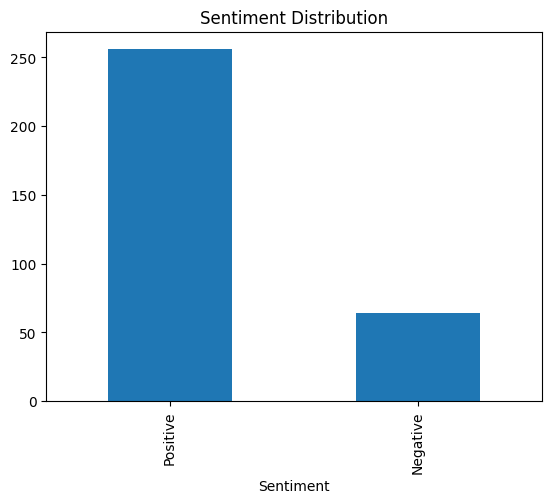

In [8]:

import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()
